# Stacking and Blending in Machine Learning (End-to-End Notes)

---

## 1. What is Ensemble Learning?

Ensemble learning is a technique where **multiple models are combined** to achieve better performance than any single model.

### Why ensembles work

* Different models make **different mistakes**
* Combining them reduces **bias + variance**
* Improves **generalization**

### Main ensemble types

* Bagging (e.g., Random Forest)
* Boosting (e.g., XGBoost, AdaBoost)
* **Stacking**
* **Blending**

This note focuses on **Stacking and Blending**.

---

## 2. Intuition Before Formal Definition

Imagine:

* Model A is good at linear patterns
* Model B is good at nonlinear patterns
* Model C handles noise well

Instead of choosing one, we **learn how to combine their predictions** using another model.

That idea = **Stacking / Blending**.

---

## 3. Stacking (Stacked Generalization)

### 3.1 Definition

**Stacking** is an ensemble method where:

1. Multiple base models are trained
2. Their predictions are used as features
3. A **meta-model** learns how to best combine them

Formally:

* Level-0 models → Base learners
* Level-1 model → Meta learner

---

## 3.2 Architecture of Stacking

```
Training Data
   ↓
Base Models (M1, M2, M3)
   ↓ predictions
Meta Dataset (P1, P2, P3)
   ↓
Meta Model
   ↓
Final Prediction
```

---

## 3.3 Why Naive Stacking Fails

❌ If base models are trained on **full training data** and predictions are reused:

* Meta-model sees **overfitted predictions**
* Leads to data leakage

✅ Solution: **Out-of-Fold (OOF) predictions**

---

## 3.4 Out-of-Fold (OOF) Predictions (Core Concept)

### Process

1. Split training data into K folds
2. For each fold:

   * Train base model on K-1 folds
   * Predict on the held-out fold
3. Collect predictions for all folds

Result:

* Every training sample has a prediction
* Prediction comes from a model that **never saw that sample**

This forms the **meta-features**.

---

## 3.5 Step-by-Step Stacking Workflow

### Step 1: Prepare data

* Split data into train and test

### Step 2: Train base models with K-Fold CV

For each base model:

* Generate OOF predictions for training set
* Train on full training data
* Predict on test set

### Step 3: Create meta dataset

* Training meta-features = OOF predictions
* Test meta-features = averaged test predictions

### Step 4: Train meta-model

* Input: meta-features
* Output: final prediction

---

## 3.6 Common Base and Meta Models

### Base models

* Linear Regression / Logistic Regression
* Decision Tree
* Random Forest
* Gradient Boosting
* SVM
* KNN

### Meta models

* Linear / Logistic Regression (most common)
* XGBoost / LightGBM
* Simple Neural Network

⚠️ Meta-model should be **simple** to avoid overfitting.

---

## 3.7 Pseudocode (Conceptual)

```python
for model in base_models:
    for fold in KFold:
        train_fold, val_fold
        model.fit(train_fold)
        oof_pred[val_fold] = model.predict(val_fold)

meta_X_train = [oof_preds_model1, oof_preds_model2, ...]
meta_model.fit(meta_X_train, y_train)
```

---

## 4. Blending

### 4.1 Definition

**Blending** is a simplified version of stacking where:

* A small **holdout validation set** is used
* No K-fold cross-validation

---

## 4.2 Architecture of Blending

```
Training Data → Base Models
Holdout Set → Base Predictions → Meta Model
Test Data → Base Predictions → Meta Model
```

---

## 4.3 Blending Workflow

1. Split data into:

   * Train set (e.g., 80%)
   * Holdout set (e.g., 20%)

2. Train base models on train set

3. Predict on holdout set

4. Train meta-model on holdout predictions

5. Predict on test data

---

## 4.4 Key Difference: Stacking vs Blending

| Aspect         | Stacking    | Blending       |
| -------------- | ----------- | -------------- |
| Validation     | K-Fold CV   | Single holdout |
| Data usage     | Efficient   | Less efficient |
| Overfitting    | Lower       | Higher         |
| Complexity     | Higher      | Lower          |
| Industry usage | Very common | Less common    |

---

## 5. When to Use What

### Use Stacking when:

* Dataset is small/medium
* You need maximum performance
* You can afford computation

### Use Blending when:

* Dataset is large
* You want simplicity
* Quick experimentation

---

## 6. Practical Tips (Very Important)

* Base models should be **diverse**
* Don’t stack very similar models
* Normalize predictions if scales differ
* Avoid deep meta-models
* Always validate with unseen data

---

## 7. Common Mistakes

❌ Data leakage in stacking
❌ Too many base models
❌ Overfitting meta-model
❌ Using weak base models

---

## 8. Real-World Usage

* Kaggle competitions
* Credit scoring
* Recommendation systems
* Forecasting

Stacking often gives **last 1–3% boost** that wins competitions.

---

## 9. One-Line Summary

> **Stacking learns how to combine models, blending approximates it.**

---


In [13]:
from sklearn.datasets import load_iris
from numpy import mean
from numpy import std
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = load_iris()
df = pd.DataFrame()

In [3]:
x  = data.data
y = data.target

In [4]:
x 

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [9]:
# get a stacking ensemble of models

def get_stacking():
    base_model = list()
    base_model.append(('lr' , LogisticRegression()))
    base_model.append(('knn' , KNeighborsClassifier()))
    base_model.append(('cart' ,DecisionTreeClassifier()))
    base_model.append(('svm' , SVC()))
    base_model.append(('bayes' , GaussianNB()))
    meta_model = LogisticRegression()
    model = StackingClassifier(estimators=base_model , final_estimator= meta_model , cv=5)
    return model
    

In [10]:
#get list of model to evaluate 
def get_models():
    models = dict()
    models['LogisticRegression'] = LogisticRegression()
    models['KNeighborsClassifier'] = KNeighborsClassifier()
    models['DecisionTreeClassifier'] = DecisionTreeClassifier()
    models['SVC'] = SVC()
    models['GaussianNB'] = GaussianNB()
    models['stacking'] = get_stacking()
    return models


In [11]:
def evaluate_model(model):
    cv = RepeatedStratifiedKFold(n_repeats=3 , n_splits=10 ,random_state=1)
    scores = cross_val_score(model , x , y , scoring='accuracy' , cv = cv , n_jobs=-1 , error_score='raise')
 
    return scores

In [12]:
models = get_models()

In [14]:
results , names = list() , list()
for name , model in models.items():
    scores = evaluate_model(model)
    results.append(scores)
    names.append(name)
    print('>%s -> %.3f (%.3f)---Iris Dataset' %
          (name, mean(scores), std(scores)))

>LogisticRegression -> 0.964 (0.041)---Iris Dataset
>KNeighborsClassifier -> 0.964 (0.037)---Iris Dataset
>DecisionTreeClassifier -> 0.951 (0.054)---Iris Dataset
>SVC -> 0.964 (0.045)---Iris Dataset
>GaussianNB -> 0.956 (0.047)---Iris Dataset
>stacking -> 0.962 (0.041)---Iris Dataset


C:\Users\Acer\AppData\Local\Temp\ipykernel_4548\3502484742.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=[s+"-Iris" for s in names], showmeans=True)


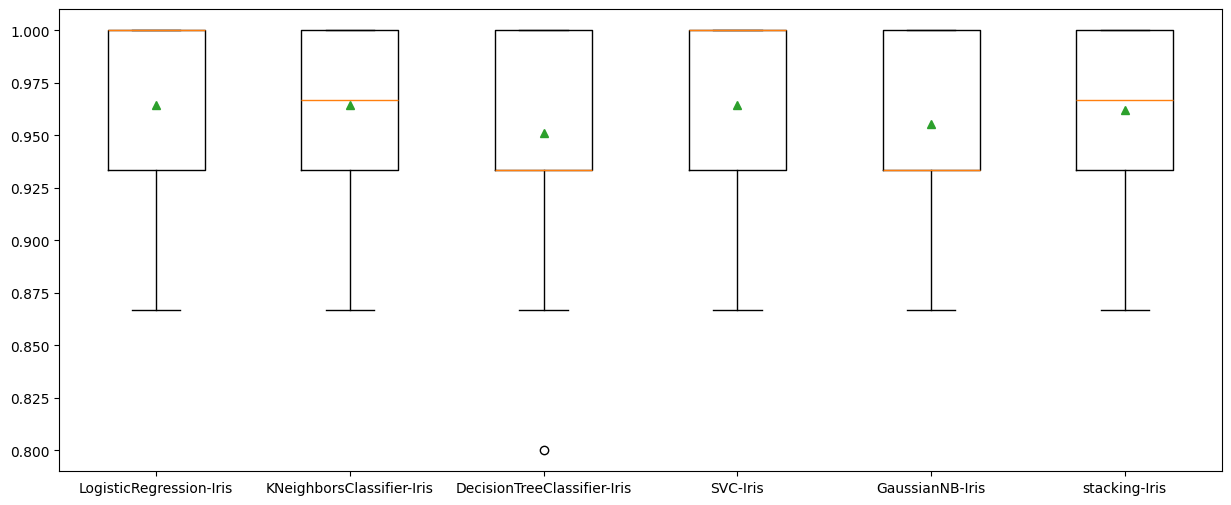

In [15]:
# plot model performance for comparison
plt.rcParams["figure.figsize"] = (15, 6)
plt.boxplot(results, labels=[s+"-Iris" for s in names], showmeans=True)
plt.show()
